    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    Task 11: Implement a program which (a) given a feature model or latent space, (b) a value n, (c) a value m, and (d) a label l
        –   creates a similarity graph, G(V, E), where V corresponds to the images in the database and E contains node pairs Vi , Vj 
            such that, for each subject Vi, Vj is one of the n most similar images in the database in the given space

        –   identifies the most significant m images (relative to the given label l) using personalized PageRank measure. 
            See Huang, S., Li, X., Candan, K. S., Sapino, M. L. (2016). Reducing seed noise in personalized PageRank.
            Social Network Analysis and Mining, 6(1), 1-25.


In [21]:
FEATURE_SPACE_INPUT = input(
"""
Provide a feature model or latent space that was generated using tasks 3 to 6.

Feature space: [color, hog, avgpool, layer3, fc]

For latent semantics:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_5_svd".
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

N = int(input(
"""
Enter n - the count of most similar images in the database in the given space
"""
))

M = int(input(
"""
Enter m - the count of most significant images in the label to be returned as output of Personalized PageRank Algorithm
"""
))

L = input(
"""
Provide l - the label for which you want to find similar labels
"""
)

In [22]:
# Get feature space
# todo: print reducer and feature space used
# todo: implement for latent space, what distance function to use for latent spaces, same as the feature space??

from utils.database_utils import retrieve
from utils.vector_utils import get_latent_feature_vectors

if FEATURE_SPACE_INPUT in ['color', 'hog', 'avgpool', 'layer3', 'fc', 'resnet']:
    FEATURE_SPACE_NAME = FEATURE_SPACE_INPUT
    feature_space = retrieve(f'{FEATURE_SPACE_INPUT}.pt')
    print(f"Feature Space: {FEATURE_SPACE_INPUT}")
else:
    print(FEATURE_SPACE_INPUT)
    LATENT_SPACE = FEATURE_SPACE_INPUT.split('_')[0]
    print(LATENT_SPACE)
    
    FEATURE_SPACE_NAME = FEATURE_SPACE_INPUT.split('_')[1]
    print(FEATURE_SPACE_NAME)

    # Load created latent space
    reducer = retrieve(f'{FEATURE_SPACE_INPUT}_reducer.pt')

    feature_vectors = retrieve(f'{FEATURE_SPACE_NAME}.pt')
    feature_space = get_latent_feature_vectors(feature_vectors, reducer)


Feature Space: layer3


In [23]:
# Create a map from labels to image_ids
label2imageids = {}
for image_id, (label, _) in feature_space.items():
    if label not in label2imageids:
        label2imageids[label] = []

    label2imageids[label].append(image_id)

In [24]:
# Generate a similarity graph between images

from utils.database_utils import exists, compressed_retrieve, compressed_store
from utils.distance_utils import get_distance_fn, distance_matrix
import numpy as np

if exists(f'distance_matrix_{FEATURE_SPACE_INPUT}.pt'):
    dm = compressed_retrieve(f'distance_matrix_{FEATURE_SPACE_INPUT}.pt')
else:
    dm = distance_matrix(feature_space, get_distance_fn(FEATURE_SPACE_NAME))
    compressed_store(dm, f'distance_matrix_{FEATURE_SPACE_INPUT}.pt')

similarity_graph = np.zeros((len(dm), len(dm)), dtype=float)
for i, row in enumerate(dm):
    similarity_graph[i][np.argsort(row)[:N]] = 1
similarity_graph

array([[1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [25]:
# Compute Personalized PageRank

transition_matrix = (similarity_graph / N).T
lbl_indexes = np.array(label2imageids[L]) // 2
damping_factor = 0.85
pr = np.full(len(similarity_graph), 1/len(similarity_graph), dtype=float)
s = np.zeros(len(similarity_graph), dtype=float)
s[lbl_indexes] = 1 / len(lbl_indexes)
iterations = 50

for i in range(iterations):
    pr = ((damping_factor * transition_matrix) @ pr) + ((1 - damping_factor) * s)

Files already downloaded and verified



Query Label: Faces


1 .	Image ID:  22 		Label:  Faces 		PageRank:  0.02807801454469039


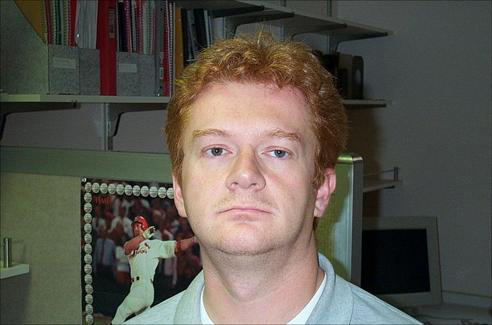

2 .	Image ID:  218 		Label:  Faces 		PageRank:  0.0237539494623686


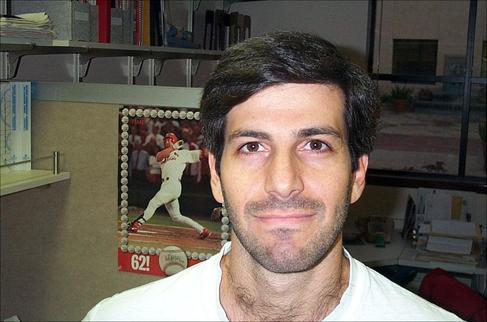

3 .	Image ID:  368 		Label:  Faces 		PageRank:  0.02315694908498618


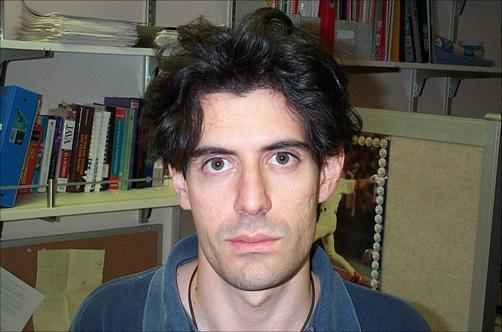

4 .	Image ID:  36 		Label:  Faces 		PageRank:  0.020318318051047193


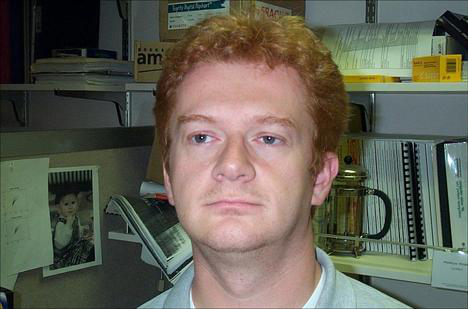

5 .	Image ID:  422 		Label:  Faces 		PageRank:  0.019944564520978474


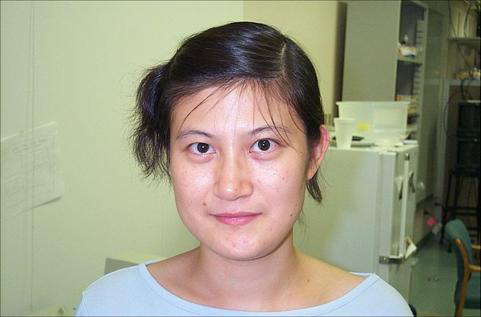

6 .	Image ID:  224 		Label:  Faces 		PageRank:  0.014797294279892594


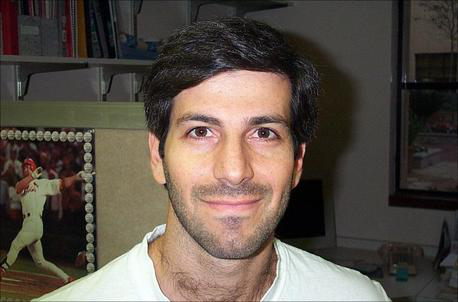

7 .	Image ID:  372 		Label:  Faces 		PageRank:  0.013727542704027585


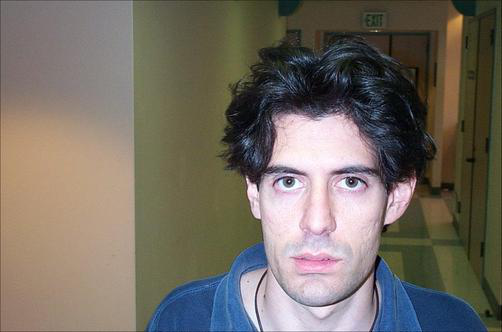

8 .	Image ID:  150 		Label:  Faces 		PageRank:  0.013499876795176594


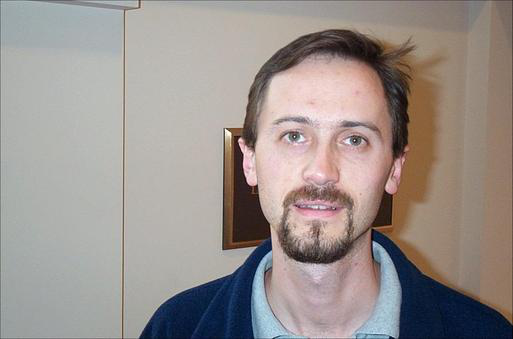

9 .	Image ID:  280 		Label:  Faces 		PageRank:  0.01347789098437978


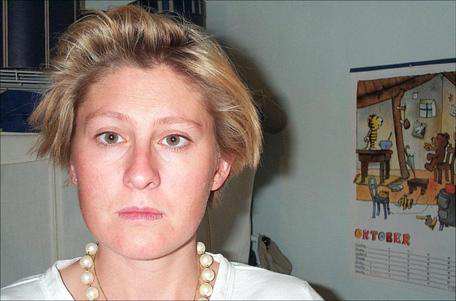

10 .	Image ID:  144 		Label:  Faces 		PageRank:  0.013100435385392895


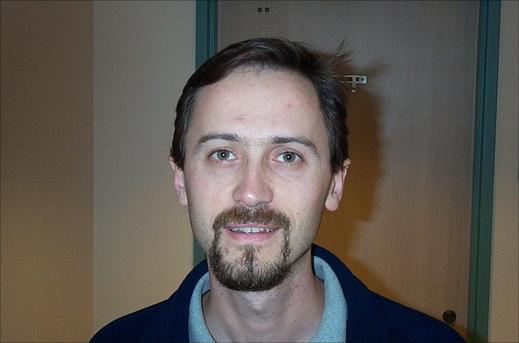

In [26]:
# Get top M significant images related to the provided label

top_m = []

for idx in np.argsort(pr)[:-M-1:-1]:
    imgid = idx * 2
    label = feature_space[imgid][0]
    pr_score = pr[idx]
    top_m.append((imgid, label, pr_score))

from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

print(f"\n\n\nQuery Label: {L}\n\n")

for i, (image_id, label, pagerank_score) in enumerate(top_m):
    print(i+1, ".\tImage ID: ", image_id, "\t\tLabel: ", label, "\t\tPageRank: ", pagerank_score)
    display(dataset[image_id][0])